This is Part Two of a three-part project, intended to demonstrate various skills in the use of Python and the Pandas library for the purposes of data analysis and (to some extent) data science.

Here, we will briefly explore three possible correlations as candidates for a more in-depth analysis to be undertaken in Part Three. We will ultimately settle on the third candidate and lay some groundwork necessary for the said in-depth analysis.

In [11]:
# Utilized Dataset: Armingeon, Klaus, Sarah Engler, Lucas Leemann and David Weisstanner (2024): Comparative Political Data Set (CPD) 1960-2022. Zurich/Lueneburg/Lucerne: University of Zurich, Leuphana University Lueneburg, and University of Lucerne.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_original = pd.read_excel("https://cpds-data.org/wp-content/uploads/2024/11/cpds-1960-2022-update-2024-2.xlsx")

redundant_year_columns = [column for column in df_original.columns if column.startswith('year_')]
redundant_country_columns = [column for column in df_original.columns if column.startswith('country_')]
redundant_columns = redundant_year_columns + redundant_country_columns
df_new = df_original.drop(redundant_columns, axis=1)

from codebook import CodeBook, codebook_dict
code = CodeBook(codebook_dict)

df_cpd = df_new[df_new.columns.intersection(codebook_dict)].copy()
df_cpd.sample(5)

,year,country,poco,eu,emu,gov_right1,gov_cent1,gov_left1,gov_party,gov_new,...,earretir_pmp,emprot_reg,emprot_temp,prefisc_gini,pretran_gini,postfisc_gini,pop,pop15_64,pop65,elderly
1654,2000,Sweden,0.0,1.0,0.0,0.000000,0.000000,100.000000,5.0,0.0,...,0.055,2.494,1.437,40.3,40.5,25.6,8872.1,5705.1,1531.7,17.264233
312,1980,Cyprus,0.0,0.0,0.0,69.200199,0.000000,12.617983,2.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,509.1,NaN,NaN,NaN
797,1990,Iceland,0.0,0.0,0.0,18.180000,27.270000,54.550000,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,254.8,164.1,27.1,10.635793
540,2018,Finland,0.0,1.0,1.0,58.823529,41.176471,0.000000,1.0,0.0,...,0.000,2.000,1.562,NaN,NaN,NaN,5516.2,3437.1,1192.1,21.610892
1215,1975,Netherlands,0.0,1.0,0.0,12.500000,31.250000,56.250000,3.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,13660.0,8728.3,1474.8,10.796486


## Voter Turnout and Education Funding

Since the correlation between an electorate's education and a country's voter turnout is a subject of extensive research in political science (e.g., Burden (2009) "The Dynamic Effects of Education on Voter Turnout," Inkinen & Saari (2019) "The Educational Correlates of Voting," and Chevalier & Doyle (2012) "Schooling and Voter Turnout"), it seems legitimate to investigate whether such relationships can be traced back to one of the most important factors influencing a population's education – government spending on education. The CPD contains a column tracking this variable (as well as an interpolated version, providing consistent yearly entries), along with a column tracking voter turnout.

To get a rough idea of whether there is potential for further investigation of this relationship, let's group the data by country and plot the mean values of the "educexp_gov_ipol" and "vturn" columns.

In [12]:
code.educexp_gov, code.educexp_gov_ipol, code.vturn

('General government expenditure on education (current, capital and transfers) as a percentage of GDP. It includes expenditure funded by transfers from international sources to government.',
 'Linear interpolation of the variable ‘educexp_gov’',
 'Voter turnout in election')

In [13]:
# exclude countries with compulsory voting
country_list = df_cpd[~df_cpd["country"].isin(["Australia", "Belgium", "Luxembourg", "Greece"])]["country"].unique().tolist()

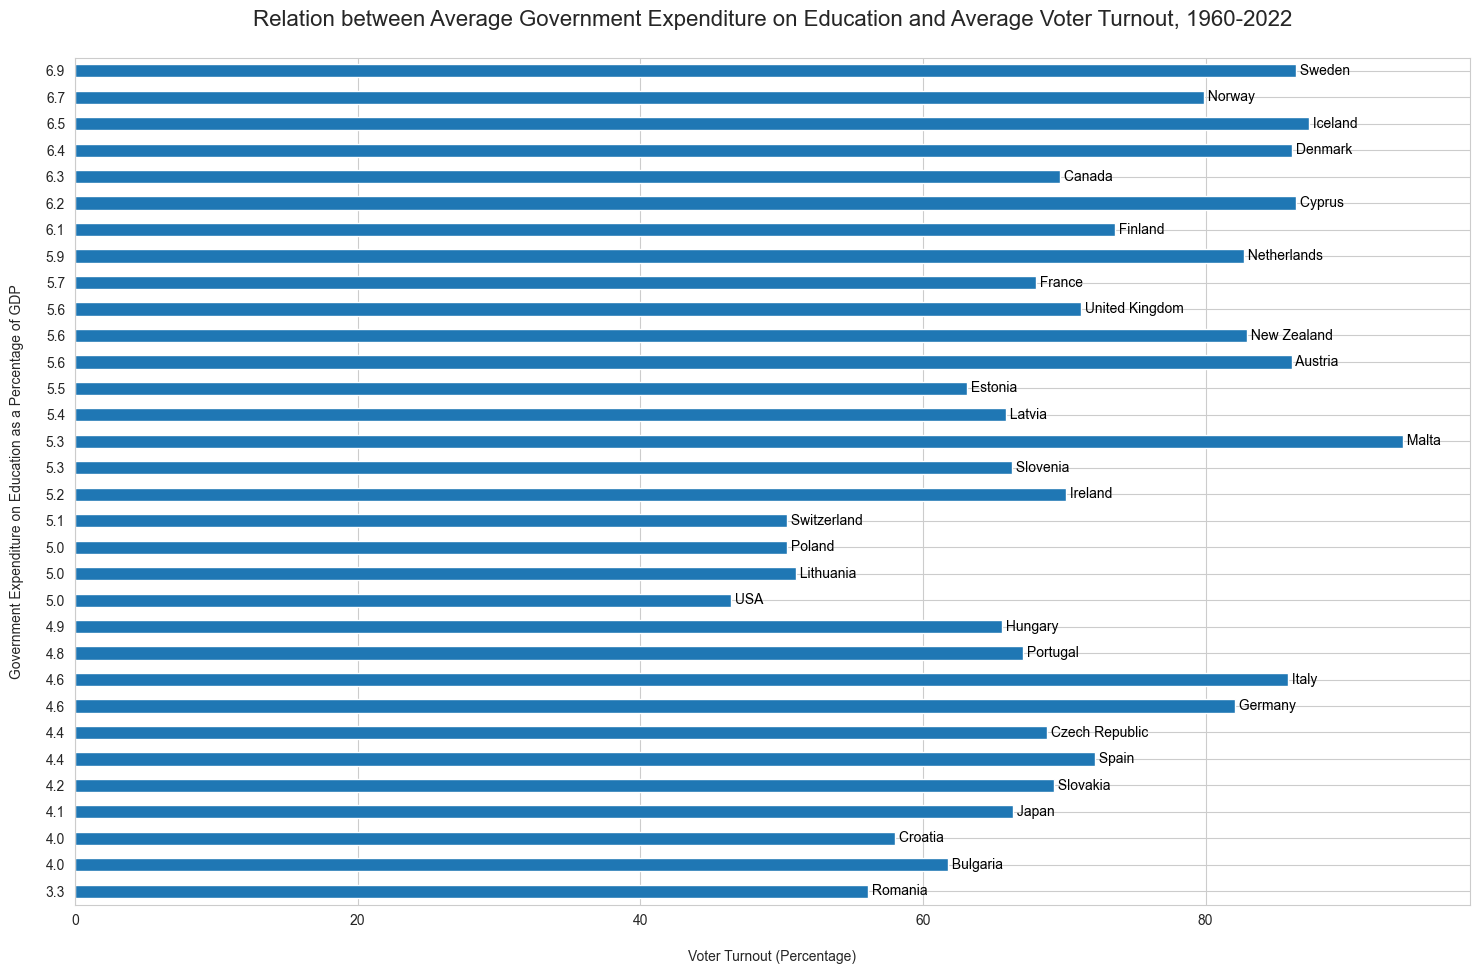

In [14]:
df_plot = df_cpd[df_cpd["country"].isin(country_list) & (df_cpd["year"] > 1960)].groupby("country")[["educexp_public_ipol", "vturn"]].mean().round(1).sort_values("educexp_public_ipol")
ax = df_plot.plot(kind="barh", x="educexp_public_ipol", y="vturn", figsize=(18, 11))

for idx, value in enumerate(df_plot['vturn']):
    ax.text(value, idx, f" {df_plot.index[idx]}", va='center', ha='left', fontsize=10, color='black')

plt.ylabel("Government Expenditure on Education as a Percentage of GDP\n")
plt.xlabel("\nVoter Turnout (Percentage)")
plt.title("Relation between Average Government Expenditure on Education and Average Voter Turnout, 1960-2022\n", fontsize=16)
plt.legend().set_visible(False)
plt.show()

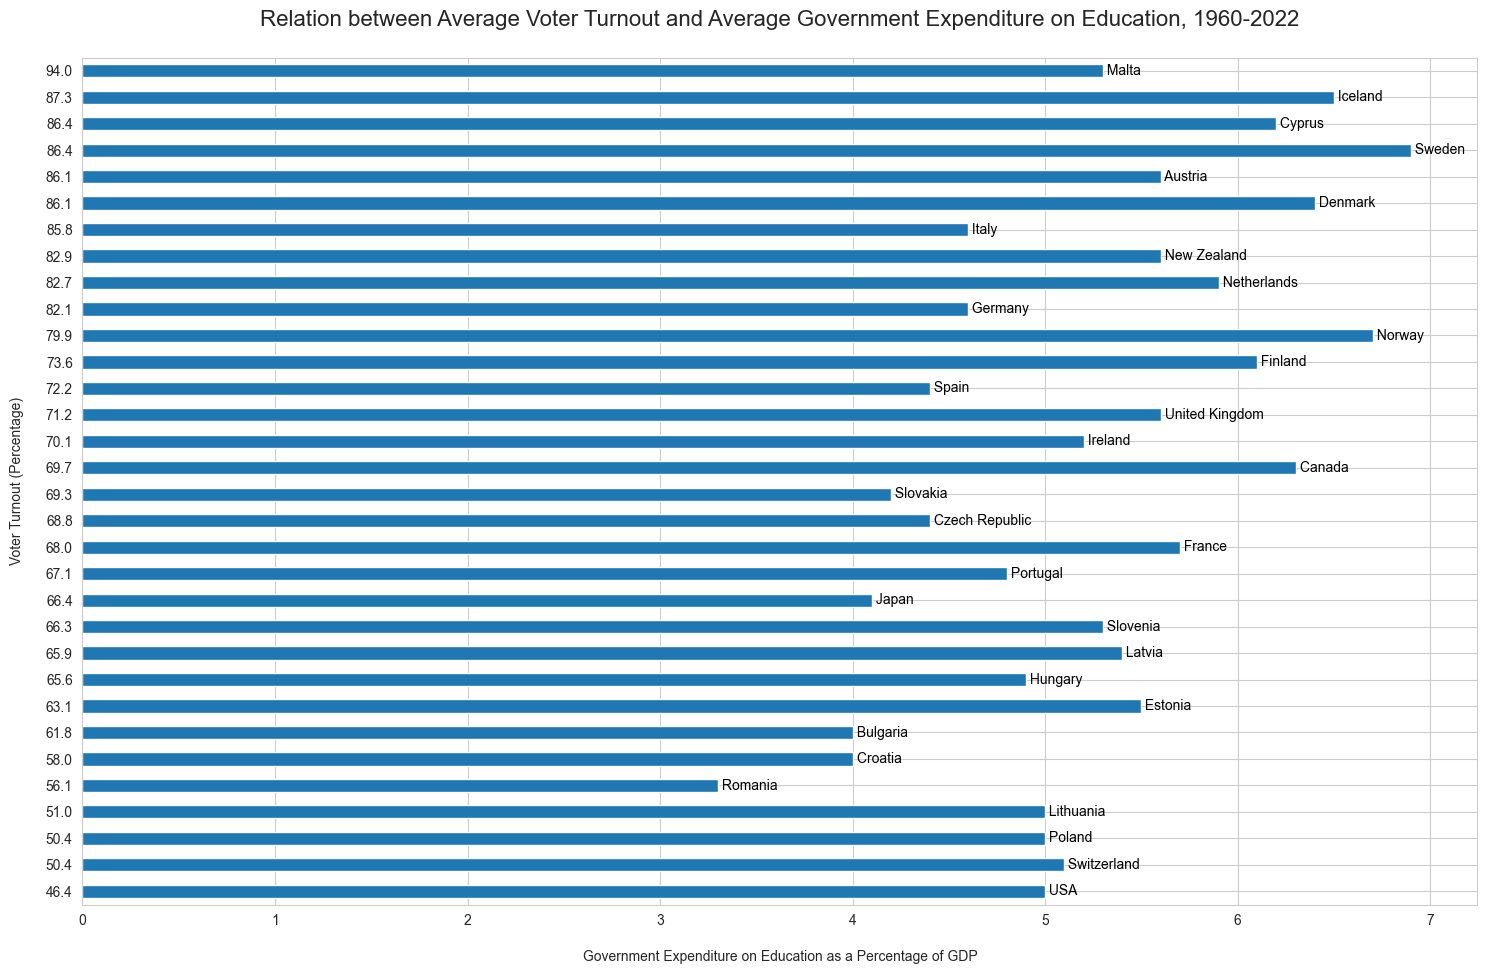

In [15]:
df_plot = df_cpd[df_cpd["country"].isin(country_list) & (df_cpd["year"] > 1960)].groupby("country")[["vturn", "educexp_public_ipol"]].mean().round(1).sort_values("vturn")
ax = df_plot.plot(kind="barh", x="vturn", y="educexp_public_ipol", figsize=(18, 11))

for idx, value in enumerate(df_plot['educexp_public_ipol']):
    ax.text(value, idx, f" {df_plot.index[idx]}", va='center', ha='left', fontsize=10, color='black')

plt.xlabel("\nGovernment Expenditure on Education as a Percentage of GDP")
plt.ylabel("Voter Turnout (Percentage)\n")
plt.title("Relation between Average Voter Turnout and Average Government Expenditure on Education, 1960-2022\n", fontsize=16)
plt.legend().set_visible(False)
plt.show()

If government spending on education and voter turnout were positively correlated, we should expect to see a pattern of increasing bar sizes from the bottom to the top of the chart. Although there are numerous outliers, there appears to be a rough pattern of that nature. Following up on that initial observation could include looking at both variables over time on a country-by-country basis, taking private education expenditure into account to see if it might help to explain the outliers (if they are indeed outliers), and looking for correlations between voter turnout and other education-related variables for contrast and comparison.

## Unemployment Rates and Spending on Labor Market Initiatives

CPD contains a large amount of data regarding each country's yearly expenditure on a variety of labor market initiatives, including training programs, recruitment incentives, public sector job creation, and support for startups. Presumably, one of the purposes of these expenditures is to achieve reductions in unemployment. Therefore, there is an obvious interest in understanding how effective each of the programs is in contributing to that end. A good starting point for such an analysis might look like this:

We pick a single country (in this case, Germany) and select all the relevant columns where they contain entries for that country. We create a line plot for each of the four labor market-related initiatives mentioned. The values of the column concerning yearly expenditure for each initiative make up the y-axis depicted on the right. The y-axis depicted on the left is constituted by the values of the unemployment rate column. The x-axis will represent time (in years).

In [16]:
for i in ["unemp", "training_pmp", "incent_pmp", "jobcrea_pmp", "startup_pmp"]:
    print(f"{i}: {getattr(code, i)}\n")

unemp: Unemployment rate, percentage of civilian labour force

training_pmp: Public and mandatory private expenditure on labour market training as a percentage of GDP

incent_pmp: Public and mandatory private expenditure on employment incentives (recruitment and employment maintenance incentives) as a percentage of GDP

jobcrea_pmp: Public and private mandatory expenditure on direct job creation (usually in the public or non-profit sector) as a percentage of GDP

startup_pmp: Public and mandatory private support of unemployed persons (or closely-related groups) starting enterprises or becoming self-employed as a percentage of GDP



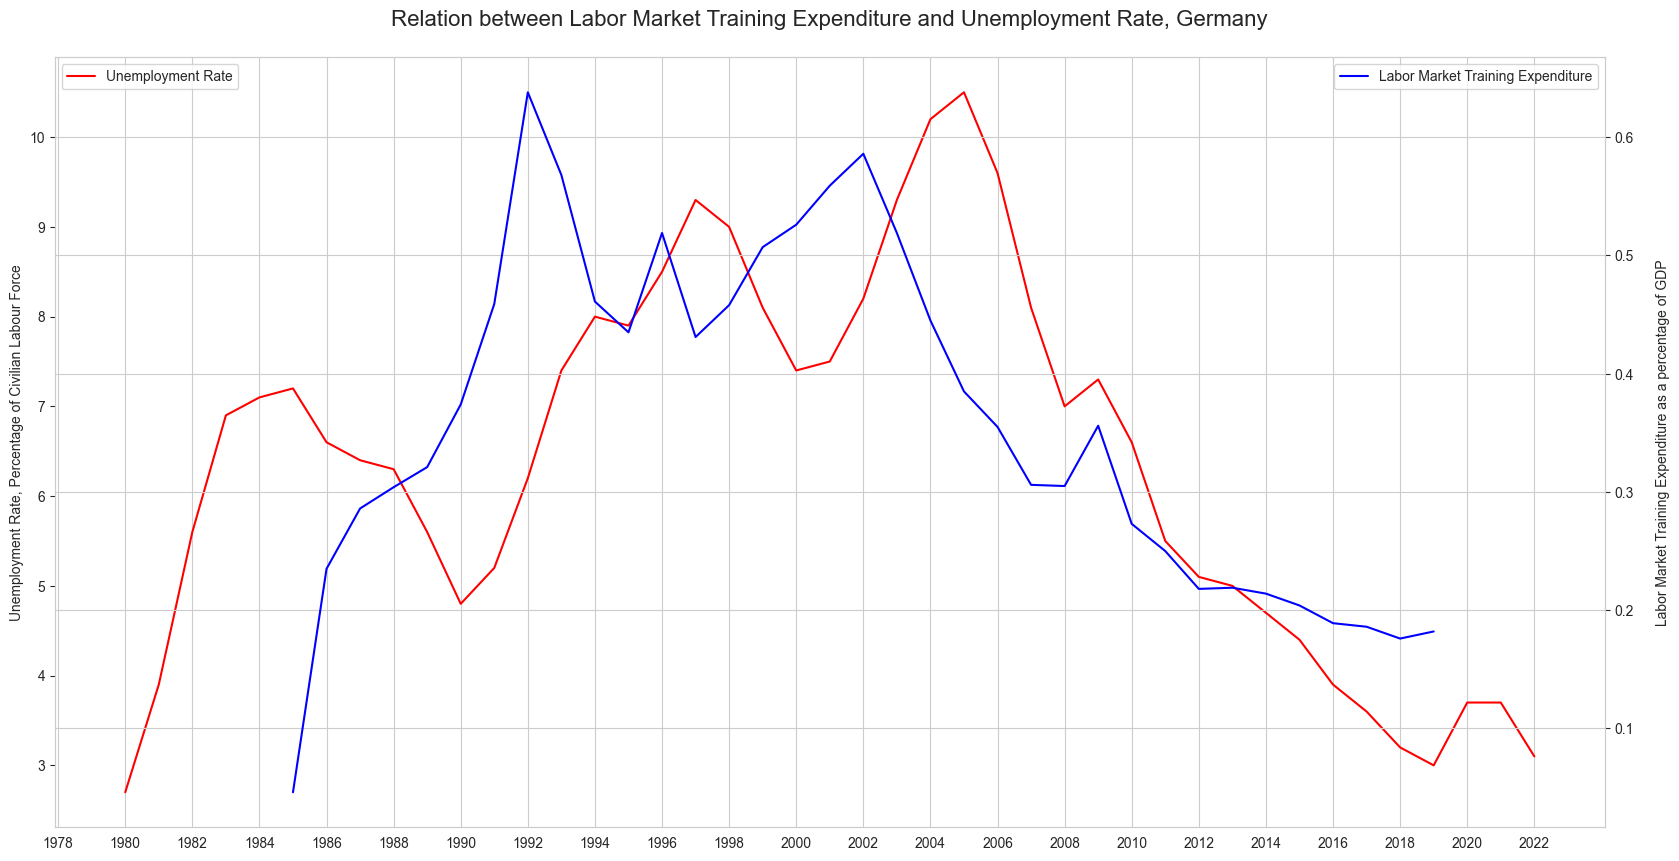

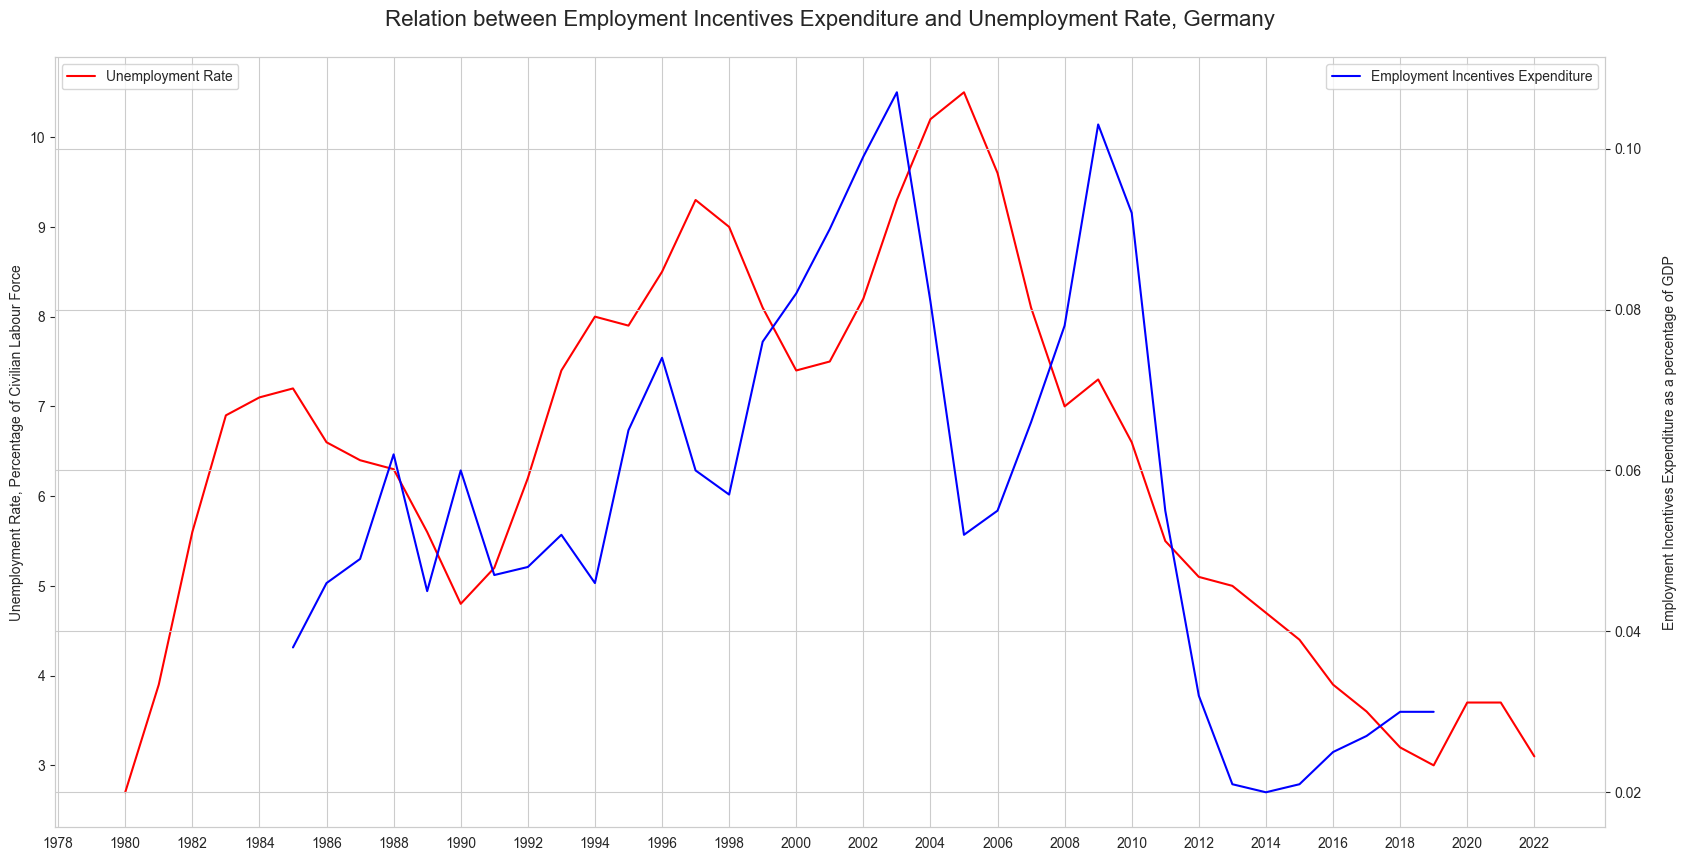

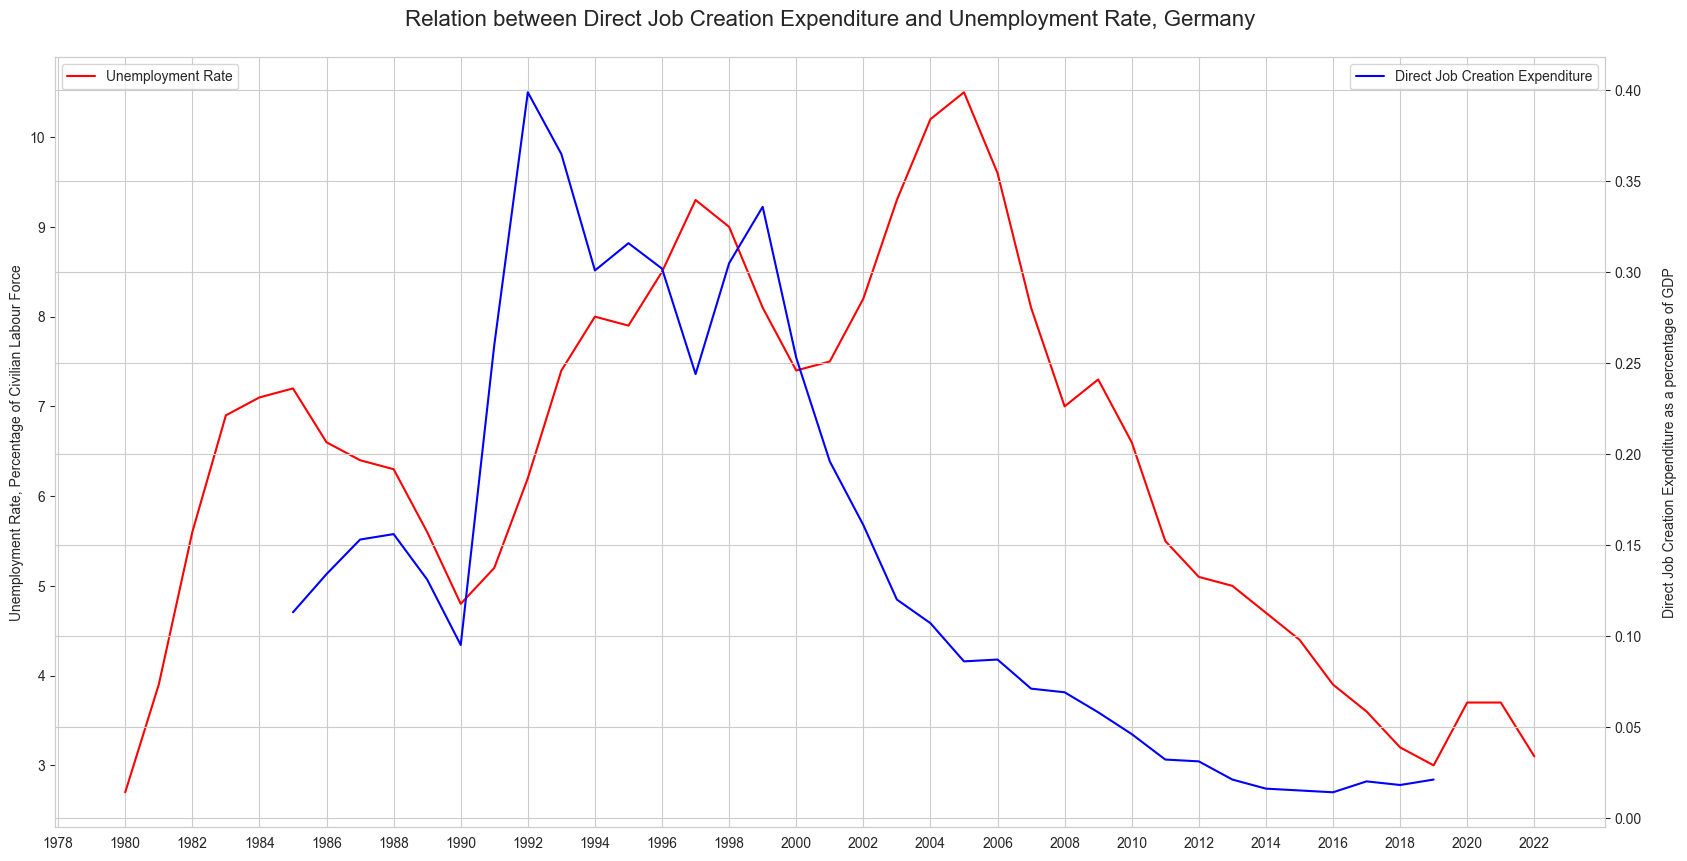

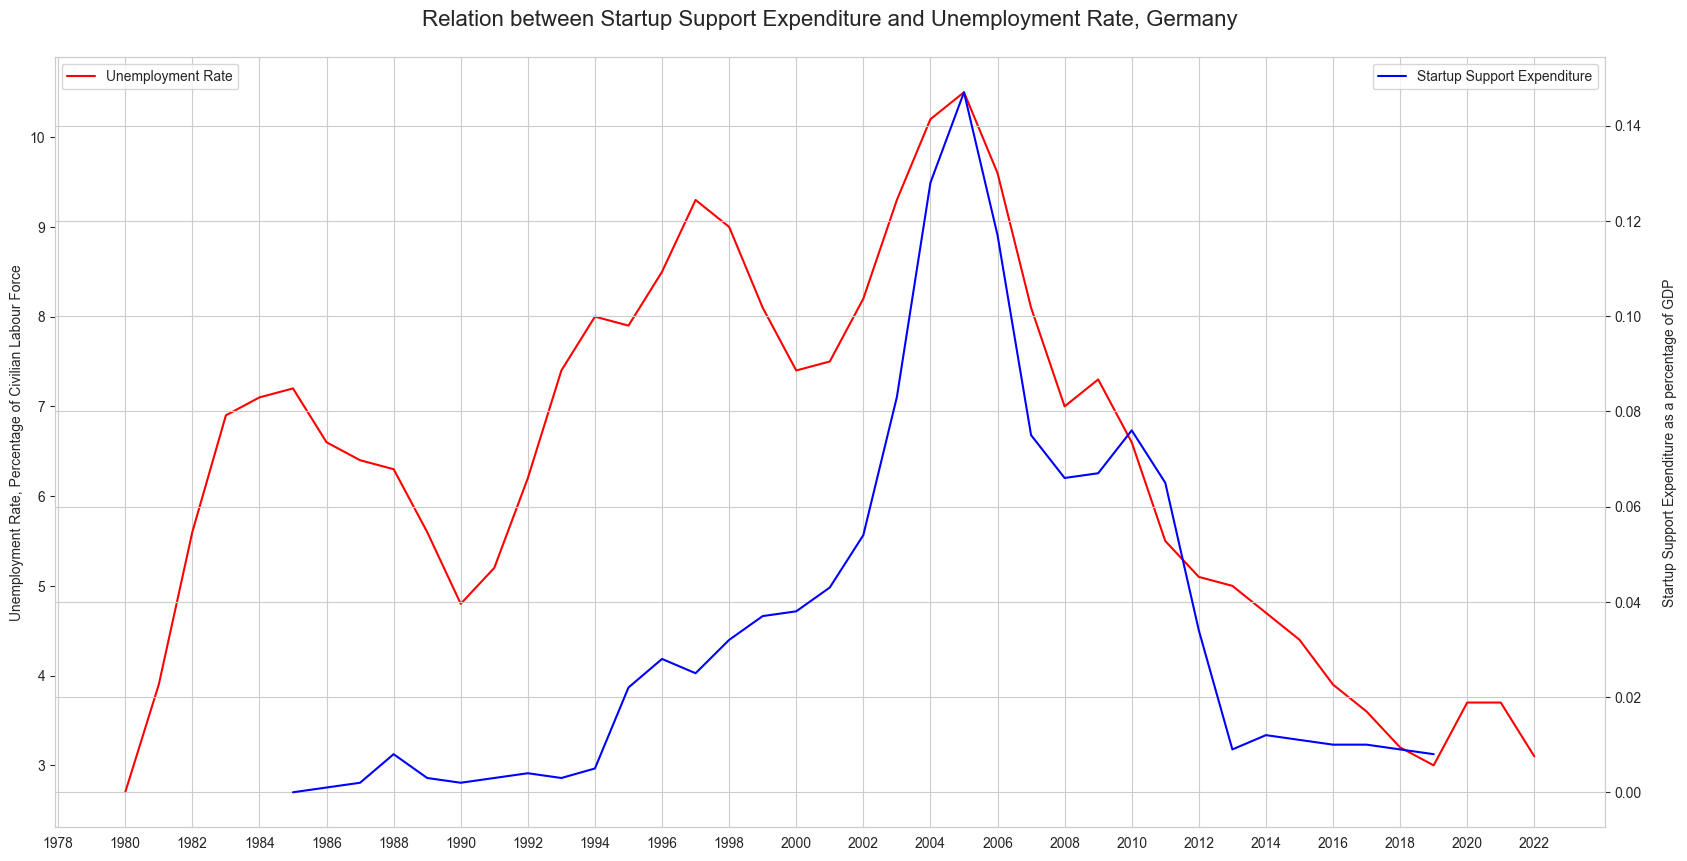

In [43]:
plot_label_dict = {"training_pmp": ["Labor Market Training Expenditure", "Labor Market Training Expenditure as a percentage of GDP"],
                   "incent_pmp": ["Employment Incentives Expenditure", "Employment Incentives Expenditure as a percentage of GDP"],
                   "jobcrea_pmp": ["Direct Job Creation Expenditure", "Direct Job Creation Expenditure as a percentage of GDP"],
                   "startup_pmp": ["Startup Support Expenditure", "Startup Support Expenditure as a percentage of GDP"]
                   }


df_ger = df_cpd[df_cpd["country"] == "Germany"][["year", "country", "unemp", "training_pmp", "incent_pmp", "jobcrea_pmp", "startup_pmp"]]

for exp in plot_label_dict:

    fig_, ax1 = plt.subplots()
    fig_.set_size_inches(20, 10)

    ax1.plot(df_ger[df_ger["year"] >= 1980]["year"], df_ger[df_ger["year"] >= 1980]["unemp"], color="red", label="Unemployment Rate")
    ax1.set_xticks(np.arange(df_ger["year"].min(), df_ger["year"].max() + 1, 2))
    ax1.set_ylabel("Unemployment Rate, Percentage of Civilian Labour Force")


    ax2 = ax1.twinx()
    ax2.plot(df_ger["year"], df_ger[exp], color="blue", label=plot_label_dict[exp][0])
    ax2.set_ylabel(f"\n{plot_label_dict[exp][1]}")

    ax1.grid(axis="y")
    ax2.grid(axis="x")

    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.title(f"Relation between {plot_label_dict[exp][0]} and Unemployment Rate, Germany\n", fontsize=16)

    plt.show()

In all four figures (although more clearly in the first two), we can observe a rough covariation of the unemployment rate and expenditure on the labor market program depicted. At the same time, it is difficult to determine where changes in unemployment follow changes in expenditure and where changes in expenditure follow changes in unemployment. We are inclined to think that the steps required to gain better insights regarding these constellations would be quite similar to the approach we take in expanding upon the third relationship introduced in this exploratory analysis. (See comments below as well as part three of our project.)

## Identifying Predictors of Election Outcomes

The subject we want to investigate in depth concerns the degree to which various economic and government spending-related indicators can be seen as predictors of election outcomes, and how they compare to each other in predictive power. These indicators include (but are not limited to) unemployment rates, inflation rates, GDP growth, and social security transfers. We ultimately want to map substantial changes in any of these indicators onto electoral terms, the latter being separated according to whether they are followed by the election of new governments. As "substantial" changes, we will consider changes that occur over the course of at least two years and exhibit a yearly increase or decrease greater than a given country's average yearly increase or decrease for the indicator in question. Here, we will do some groundwork, to be followed up in Part Three of our project.

Since the changes we consider "substantial" must occur over a period of at least two years, and since we are ultimately interested in how these changes intersect with electoral terms, we will focus only on electoral terms that last for at least two years. As a first step, we will use a function to filter the election dates column, which contains the dates of national elections for parliament (or the lower house, if bicameral). If the "elect" column contains two election dates separated by fewer than two years, the "elect_filtered" column will only include the later date. (Alternatively, we could keep the earlier date; however, it's not immediately clear how to make this choice in a non-arbitrary way.)

In [18]:
def filter_elect_column(df):
    # initialize the elect_filtered column
    df["elect_filtered"] = pd.NaT
    # iterate over countries
    for country in df["country"].unique():
        # create a list of all non-empty entries for country's elect column
        year_list = df[(df["country"] == country) & (df["elect"].notnull())]["elect"].dt.year.tolist()
        # reversing the list affects the order in which election dates will be added to the filtered list,
        # ensuring that we keep the latter of two dates separated by less than two years
        year_list.reverse()

        # initialize the year_list_filtered containing the year of the last election
        year_list_filtered = [year_list[0]]
        for n in range(1, len(year_list)):
            # calculate the distance between two elections
            year_delta = year_list_filtered[-1] - year_list[n]
            # ignore/filter out the election dates with distance less than two years to the last election
            if year_delta < 2:
                continue
            # append the election years with the appropriate distance to year_list_filtered
            else:
                year_list_filtered.append(year_list[n])

        for year in year_list_filtered:
            # add the dates in the year_list_filtered to the elect_filtered column
            df.loc[(df["country"] == country) & (df["elect"].dt.year == year), "elect_filtered"] = df["elect"]

    return df


df_cpd = filter_elect_column(df_cpd)
df_cpd[["year", "country", "elect", "elect_filtered"]]

,year,country,elect,elect_filtered
0,1960,Australia,NaT,NaT
1,1961,Australia,1961-12-09,1961-12-09
2,1962,Australia,NaT,NaT
3,1963,Australia,1963-11-30,1963-11-30
4,1964,Australia,NaT,NaT
...,...,...,...,...
1861,2018,USA,2018-11-06,2018-11-06
1862,2019,USA,NaT,NaT
1863,2020,USA,2020-11-03,2020-11-03
1864,2021,USA,NaT,NaT


In [19]:
code.gov_new

'New ideological composition of cabinet: (0) no change, (1) change: if cabinet ideological composition (gov_party) changed from last to present year'

Since we are interested in the predictive power of changes in various variables regarding election outcomes, we need to differentiate between election outcomes. The column in the CPD most suitable for tracking different election outcomes is "gov_new", which records changes in the ideological compositions of cabinets. One challenge is that sometimes the ideological composition of a cabinet changes without it being the result of an election (e.g., when key cabinet members are replaced by individuals with substantially different political worldviews). However, if such a change occurs around the time of an election, we consider it sufficiently likely that the change resulted from that election.

Another challenge arises from the fact that we can't simply look for a 'gov_new' change within the same year as an election, as in some countries (e.g., Germany), an election and the formation of a new government can be separated by three or four months. This creates potential problems when elections occur late in the year.

The following code adds a column, "elect_new_year", to the dataframe. This column contains the same value as the "year" column for each year in which it is determined that an election took place and resulted in a new ideological composition of the cabinet. The first condition checks if both an election and a "gov_new" change occurred within the same year. The second condition checks for elections that occur in the last four months of a given year and whether a "gov_new" change occurred in the following year, provided there was no election in that following year.

In [20]:
df_cpd["elect_new_year"] = np.where(
    ((df_cpd["elect_filtered"].notnull()) & (df_cpd["gov_new"] == 1)) |
    ((df_cpd["elect_filtered"].dt.month >= 9) & (df_cpd["gov_new"].shift(-1) == 1)) & (df_cpd["elect"].shift(-1).isnull()),
    df_cpd["elect_filtered"].dt.year, None)
df_cpd[["year", "country", "elect", "gov_new", "elect_new_year","elect_filtered"]]

,year,country,elect,gov_new,elect_new_year,elect_filtered
0,1960,Australia,NaT,0.0,None,NaT
1,1961,Australia,1961-12-09,0.0,None,1961-12-09
2,1962,Australia,NaT,0.0,None,NaT
3,1963,Australia,1963-11-30,0.0,None,1963-11-30
4,1964,Australia,NaT,0.0,None,NaT
...,...,...,...,...,...,...
1861,2018,USA,2018-11-06,0.0,None,2018-11-06
1862,2019,USA,NaT,0.0,None,NaT
1863,2020,USA,2020-11-03,0.0,None,2020-11-03
1864,2021,USA,NaT,0.0,None,NaT


The following code adds a column "elect_cntn_year" ("cntn" for continued ideological composition of cabinet), which contains years with elections which did not result in a new ideological composition of the cabinet.

In [21]:
df_cpd["elect_cntn_year"] = np.where(
    ((df_cpd["elect_filtered"].notnull()) & (df_cpd["elect_new_year"].isnull())),
    df_cpd["elect_filtered"].dt.year, None)
df_cpd[["year", "country", "gov_new", "elect", "gov_new", "elect_new_year", "elect_filtered", "elect_cntn_year"]]

,year,country,gov_new,elect,gov_new,elect_new_year,elect_filtered,elect_cntn_year
0,1960,Australia,0.0,NaT,0.0,None,NaT,None
1,1961,Australia,0.0,1961-12-09,0.0,None,1961-12-09,1961.0
2,1962,Australia,0.0,NaT,0.0,None,NaT,None
3,1963,Australia,0.0,1963-11-30,0.0,None,1963-11-30,1963.0
4,1964,Australia,0.0,NaT,0.0,None,NaT,None
...,...,...,...,...,...,...,...,...
1861,2018,USA,0.0,2018-11-06,0.0,None,2018-11-06,2018.0
1862,2019,USA,0.0,NaT,0.0,None,NaT,None
1863,2020,USA,0.0,2020-11-03,0.0,None,2020-11-03,2020.0
1864,2021,USA,0.0,NaT,0.0,None,NaT,None


In [22]:
for cntry in df_cpd["country"].unique():
    plt_yrs_cntn = df_cpd[(df_cpd["country"] == cntry) & df_cpd["elect_cntn_year"].notnull()]["elect_cntn_year"].tolist()
    plt_yrs_new = df_cpd[(df_cpd["country"] == cntry) & df_cpd["elect_new_year"].notnull()]["elect_new_year"].tolist()
    print(f"{cntry} cntn: {plt_yrs_cntn} \n {cntry} new: {plt_yrs_new}")

Australia cntn: [1961.0, 1963.0, 1966.0, 1969.0, 1977.0, 1980.0, 1987.0, 1990.0, 1993.0, 1998.0, 2001.0, 2004.0, 2010.0, 2016.0, 2019.0] 
 Australia new: [1972.0, 1975.0, 1984.0, 1996.0, 2007.0, 2013.0, 2022.0]
Austria cntn: [1962.0, 1975.0, 1979.0, 1990.0, 1995.0, 2002.0, 2008.0, 2013.0] 
 Austria new: [1966.0, 1971.0, 1983.0, 1986.0, 1999.0, 2006.0, 2017.0, 2019.0]
Belgium cntn: [1965.0, 1971.0, 1985.0, 1991.0, 1995.0, 1999.0, 2003.0, 2007.0, 2010.0, 2019.0] 
 Belgium new: [1961.0, 1968.0, 1974.0, 1978.0, 1981.0, 1987.0, 2014.0]
Bulgaria cntn: [2005.0, 2017.0, 2022.0] 
 Bulgaria new: [1991.0, 1994.0, 1997.0, 2001.0, 2009.0, 2014.0]
Canada cntn: [1963.0, 1965.0, 1968.0, 1972.0, 1974.0, 1980.0, 1984.0, 1988.0, 1993.0, 1997.0, 2000.0, 2004.0, 2006.0, 2008.0, 2011.0, 2015.0, 2019.0, 2021.0] 
 Canada new: []
Croatia cntn: [2007.0, 2020.0] 
 Croatia new: [2000.0, 2003.0, 2011.0, 2016.0]
Cyprus cntn: [1976.0, 1985.0, 1991.0, 1996.0, 2001.0, 2006.0, 2016.0, 2021.0] 
 Cyprus new: [1981.0, 201

According to the overview above there are no cases of elections resulting in new ideological compositions of cabinets for Canada, the United States, or Switzerland. Let's look at the column "gov_party" to understand why:

In [23]:
code.gov_party

'Cabinet composition (Schmidt-Index):(1) Hegemony of right-wing (and center) parties (gov_left1=0),(2) dominance of right-wing (and center) parties (0<gov_left1<=33.33),(3) balance of power between left and right (33.33<gov_left1<66.67),(4) dominance of social-democratic and other left parties (66.67<=gov_left1<100),(5) hegemony of social-democratic and other left parties (gov_left=100).'

In [24]:
df_cpd[df_cpd["country"].isin(["Germany", "USA", "Canada", "Switzerland"])].groupby("country")["gov_party"].value_counts()

country      gov_party
Canada       1.0          63
Germany      1.0          24
             3.0          16
             4.0          14
             5.0           6
             2.0           3
Switzerland  2.0          63
USA          1.0          63
Name: count, dtype: int64

While the dataframe contains five different types of ideological cabinet compositions for Germany, all entries for Canada and the US are "1" (Hegemony of right-wing (and center) parties), and all entries for Switzerland are "2" (dominance of right-wing (and center) parties), meaning there won't be any "gov_new" changes for these countries. The Schmidt-Index doesn't seem to be suitable for tracking ideological differences between the dominant parties in those countries, which means they won't be represented in our results.

### Identifying Predictors with Plots

The newly added columns provide the means for an initial graphical depiction of the relationship between election outcomes and various economic or government spending-related indicators on a country-by-country basis. The following function creates simple line plots, with one of the indicators on the y-axis and the "years" column as both the primary and secondary x-axes. The primary x-axis (bottom) uses the "elect_new_year" values as ticks and tick labels, while the secondary x-axis (top) uses the "elect_cntn_year" values as ticks and tick labels. By default, the function includes a small selection of indicators, which can be expanded as needed, and a list of the five most populous countries in the dataset. (In addition to Canada, the US, and Switzerland, Japan is omitted from the default list due to a low "gov_new" count. However, Japan will be considered in our calculations going forward.) The values for any country can be plotted by passing its name in a list to the "countries" argument (e.g., countries=["Belgium"]).

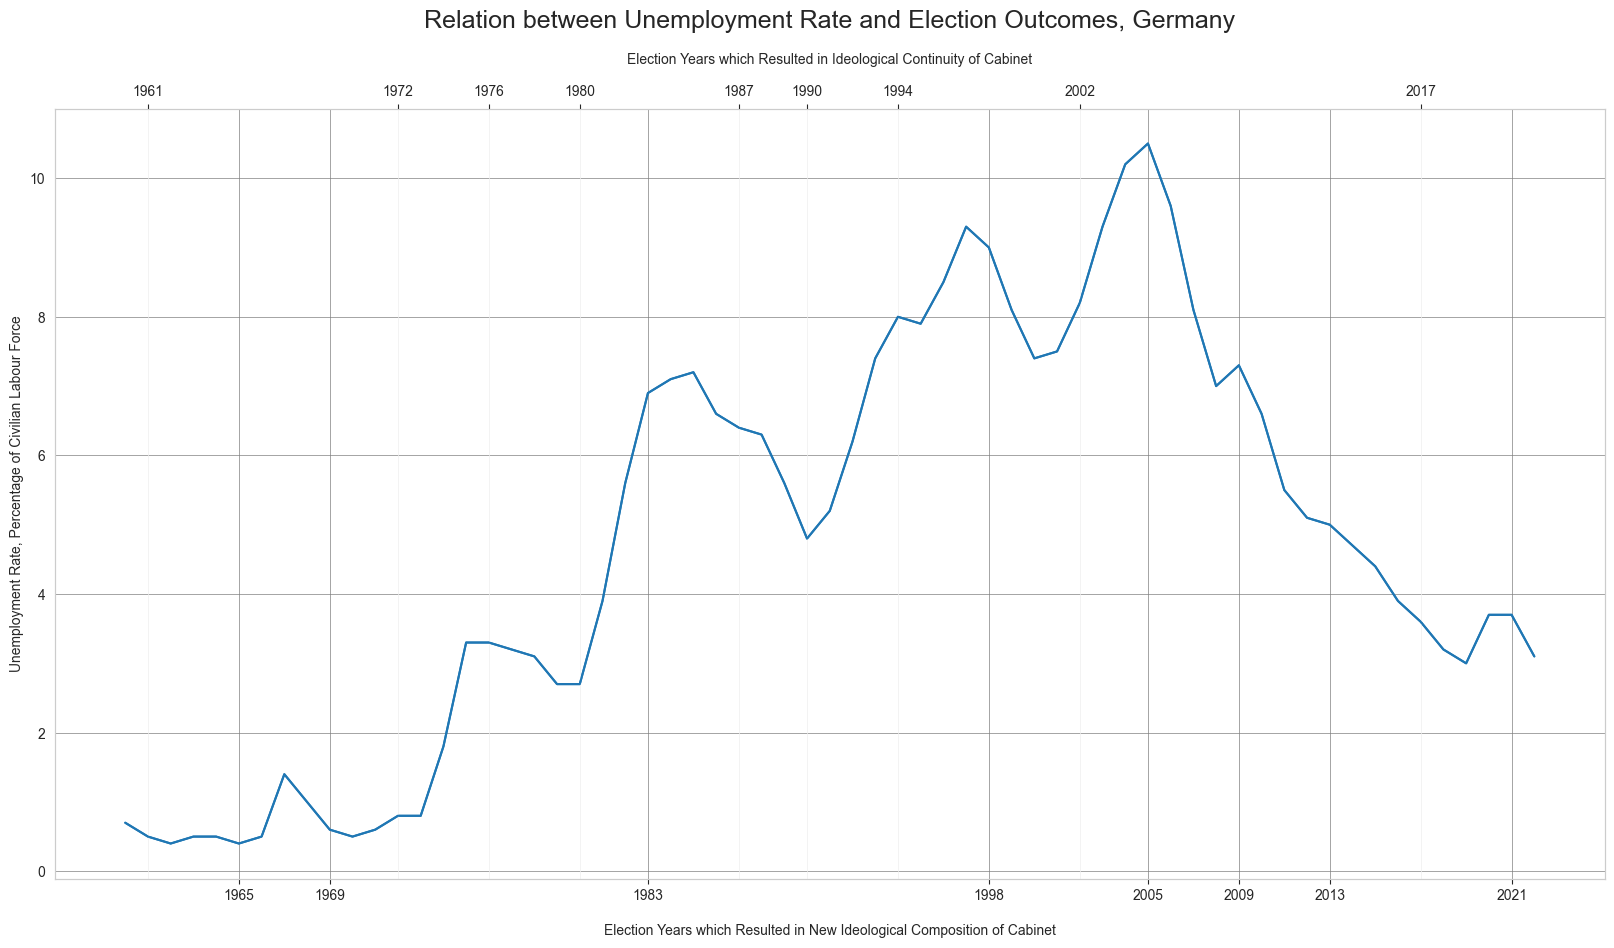

In [42]:
plot_label_dict = {
    "unemp": ["Unemployment Rate", "Unemployment Rate, Percentage of Civilian Labour Force"],
    "inflation": ["Inflation Rate", "Growth of Harmonised Consumer Price Index, Percent Change from Previous Year"],
    "sstran": ["Social Security Transfers", "Social Security Transfers as a Percentage of GDP"],
    "realgdpgr": ["GDP Growth", "Growth of Real GDP, Percent Change from Previous Year"]
}
plot_countries = df_cpd[~df_cpd["country"].isin(["Canada", "Japan", "USA", "Switzerland"])].groupby("country")["pop"].max().sort_values(ascending=False).index.tolist()

def plot_predictor(predictors=plot_label_dict, countries=plot_countries[:5]):
    for predictor in predictors:
        for country in countries:
            fig, axis_1 = plt.subplots()
            fig.set_size_inches(20, 10)

            axis_1.plot(df_cpd[df_cpd["country"] == country]["year"], df_cpd[df_cpd["country"] == country][predictor])
            axis_1.set_ylabel(plot_label_dict[predictor][1])

            axis_2 = axis_1.twiny()
            axis_2.plot(df_cpd[df_cpd["country"] == country]["year"], df_cpd[df_cpd["country"] == country][predictor])

            plot_years_new = df_cpd[(df_cpd["country"] == country) & df_cpd["elect_new_year"].notnull()]["elect_new_year"].tolist()
            plot_years_cntn = df_cpd[(df_cpd["country"] == country) & df_cpd["elect_cntn_year"].notnull()]["elect_cntn_year"].tolist()

            axis_1.set_xticks(plot_years_new)
            axis_1.set_xlabel("\nElection Years which Resulted in New Ideological Composition of Cabinet")

            axis_2.set_xticks(plot_years_cntn)
            axis_2.set_xlabel("\nElection Years which Resulted in Ideological Continuity of Cabinet\n")
            axis_2.set_xlim(axis_1.get_xlim())

            axis_1.grid(True, color="grey", linestyle="-", linewidth=0.5)
            axis_2.grid(True, color="#EEEEEE", linestyle="-", linewidth=0.5)

            plt.title(f"Relation between {plot_label_dict[predictor][0]} and Election Outcomes, {country}", fontsize=18)
            plt.show()


plot_predictor(predictors=["unemp"], countries=plot_countries[:1])

Looking at the chart depicting the German unemployment rate over time, we can see that governments with new ideological cabinet compositions were elected after steep and prolonged increases in 1983 and 2005. The electoral term preceding the election of a new government in 1998 also shows a significant increase, although it is followed by a year of slight recovery. On the other hand, there are two instances in 1976 and 1994 of sharp and prolonged increases followed by the confirmation of previous governments.

To properly assess the strength of these correlations across multiple indicators and countries, examining line plot after line plot would not be very practical or precise. Instead, we will use a series of functions to provide an organized overview of potential predictors for whether the ideological composition of cabinets is changed or upheld following an election.